# Analyse du Restaurant

Dans ce notebook, on analyse le comportement du modèle MoE que nous avons entraîné.

Objectif :
- comprendre quels experts travaillent le plus
- voir comment le gate répartit le travail
- visualiser les activations
- observer la spécialisation


In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from models.moe_layer import MoELayer

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

# chargement modele non entraine pour l instant
modele = CoucheMoE(nbExperts=4)
modele.eval()


CoucheMoE(
  (listeExperts): ModuleList(
    (0-3): 4 x ClasseExpert(
      (couche1): Linear(in_features=784, out_features=128, bias=True)
      (couche2): Linear(in_features=128, out_features=128, bias=True)
      (couche3): Linear(in_features=128, out_features=10, bias=True)
      (activation): ReLU()
    )
  )
  (gate): ClasseGating(
    (couche1): Linear(in_features=784, out_features=64, bias=True)
    (act): ReLU()
    (couche2): Linear(in_features=64, out_features=4, bias=True)
  )
)

# comment gate distribue le travail




In [2]:
transfo = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

dataset = datasets.MNIST(root="data_mnist", train=True, download=True, transform=transfo)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

donnees, labels = next(iter(loader))


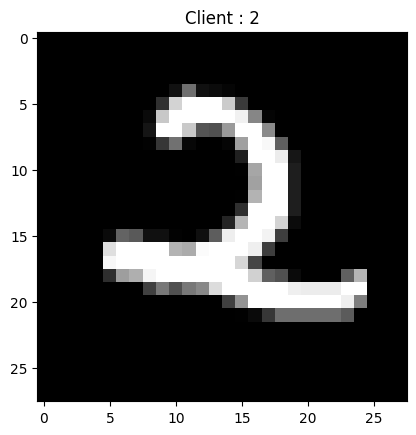

Poids du chef (gate) pour cette image :
tensor([0.2753, 0.1899, 0.2861, 0.2488], grad_fn=<SelectBackward0>)


In [3]:
import matplotlib.pyplot as plt

scores = modele.gate(donnees)
poids = F.softmax(scores, dim=1)

# afficher la 1ere image
img = donnees[0].view(28, 28)
plt.imshow(img, cmap="gray")
plt.title(f"Client : {labels[0].item()}")
plt.show()

print("Poids du chef (gate) pour cette image :")
print(poids[0])


# quel expert travaille sur quel chiffre ?

On veut une matrice 10 × 4 :
- 10 chiffres
- 4 experts
- valeur = activité moyenne



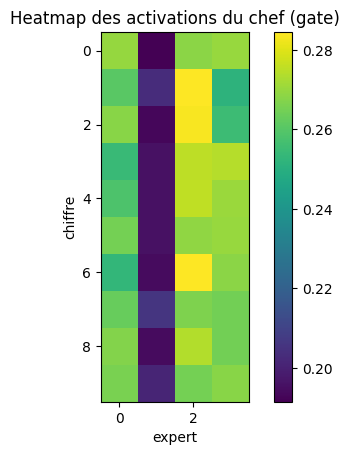

In [4]:
activ_moy = torch.zeros(10, 4)
compte = torch.zeros(10)

for donnees, labels in loader:
    scores = modele.gate(donnees)
    poids = F.softmax(scores, dim=1)

    for i in range(10):
        mask = (labels == i)
        if mask.sum() > 0:
            activ_moy[i] += poids[mask].mean(dim=0).detach()
            compte[i] += 1

    if compte.sum() > 200:
        break

activ_moy = activ_moy / compte.unsqueeze(1)
plt.imshow(activ_moy.numpy(), cmap="viridis")
plt.colorbar()
plt.xlabel("expert")
plt.ylabel("chiffre")
plt.title("Heatmap des activations du chef (gate)")
plt.show()
